# Analisis del mercado de alquiler en Espana (2011-2024)

Datos: SERPAVI (Ministerio de Vivienda) + INE (Indice de Precios de Vivienda)

In [19]:
import duckdb
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl

DB_PATH = "../data/pisos.duckdb"

def query(sql):
    con = duckdb.connect(DB_PATH, read_only=True)
    df = con.execute(sql).pl()
    con.close()
    return df

## 1. Evolucion del alquiler por CCAA (2011-2024)

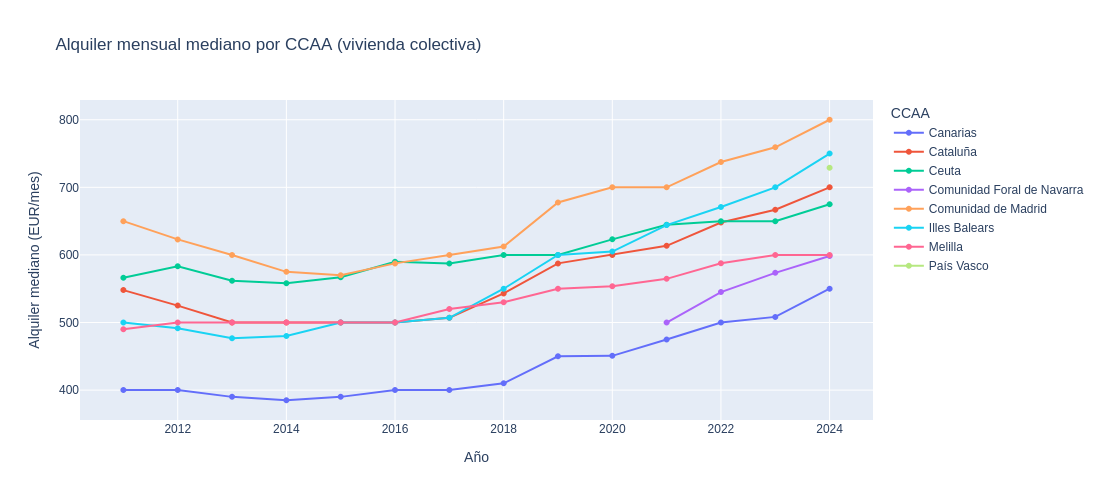

In [20]:
df_ccaa = query("""
    SELECT name, year,
        monthly_rent_median_collective as alquiler_mediano,
        rent_m2_median_collective as eur_m2
    FROM rentals
    WHERE level = 'ccaa'
        AND name IS NOT NULL AND name != ''
        AND alquiler_mediano IS NOT NULL AND NOT isnan(alquiler_mediano)
    ORDER BY name, year
""")

top_ccaa = query("""
    SELECT name FROM rentals
    WHERE level = 'ccaa' AND year = 2024
        AND monthly_rent_median_collective IS NOT NULL
        AND NOT isnan(monthly_rent_median_collective)
        AND name IS NOT NULL AND name != ''
    ORDER BY monthly_rent_median_collective DESC LIMIT 8
""")["name"].to_list()

df_top = df_ccaa.filter(pl.col("name").is_in(top_ccaa))

fig = px.line(
    df_top.to_pandas(), x="year", y="alquiler_mediano", color="name",
    title="Alquiler mensual mediano por CCAA (vivienda colectiva)",
    labels={"year": "Año", "alquiler_mediano": "Alquiler mediano (EUR/mes)", "name": "CCAA"},
    markers=True,
)
fig.update_layout(hovermode="x unified", width=900, height=500)
fig.show()

## 2. Ranking CCAA por precio/m2 en 2024

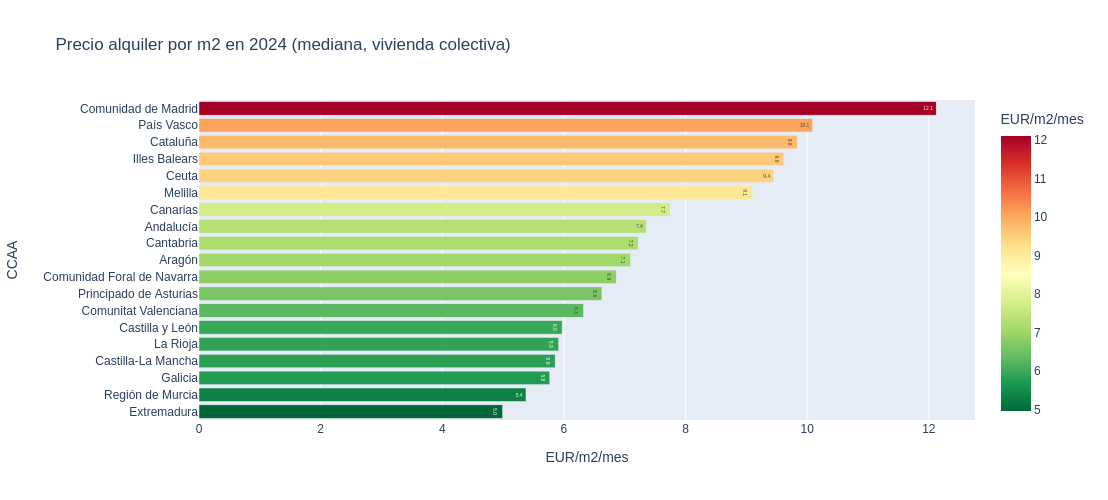

In [21]:
df_rank = query("""
    SELECT name,
        rent_m2_median_collective as eur_m2,
        monthly_rent_median_collective as alquiler,
        num_properties_collective as num_pisos
    FROM rentals
    WHERE level = 'ccaa' AND year = 2024
        AND name IS NOT NULL AND name != ''
        AND eur_m2 IS NOT NULL AND NOT isnan(eur_m2)
    ORDER BY eur_m2 DESC
""")

fig = px.bar(
    df_rank.to_pandas(), x="eur_m2", y="name", orientation="h",
    title="Precio alquiler por m2 en 2024 (mediana, vivienda colectiva)",
    labels={"eur_m2": "EUR/m2/mes", "name": "CCAA"},
    text_auto=".1f",
    color="eur_m2", color_continuous_scale="RdYlGn_r",
)
fig.update_layout(yaxis=dict(autorange="reversed"), width=900, height=500, showlegend=False)
fig.show()

## 3. Madrid: evolucion alquiler municipio + banda P25-P75

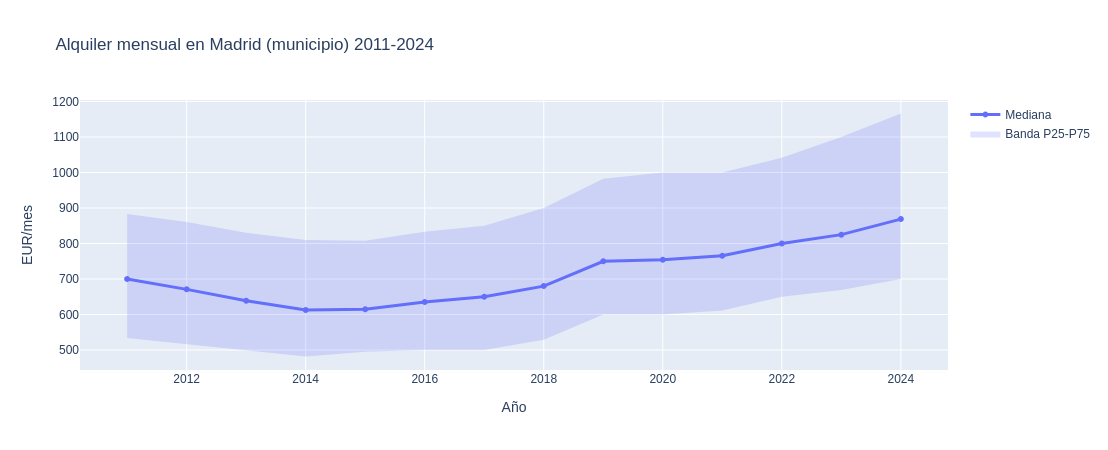

In [22]:
df_mad = query("""
    SELECT year,
        monthly_rent_median_collective as mediana,
        monthly_rent_p25_collective as p25,
        monthly_rent_p75_collective as p75,
        rent_m2_median_collective as eur_m2
    FROM rentals
    WHERE level = 'municipio' AND name = 'Madrid'
    ORDER BY year
""").to_pandas()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_mad["year"], y=df_mad["p75"], mode="lines", name="P75",
    line=dict(width=0), showlegend=False,
))
fig.add_trace(go.Scatter(
    x=df_mad["year"], y=df_mad["p25"], mode="lines", name="Banda P25-P75",
    fill="tonexty", fillcolor="rgba(99,110,250,0.2)", line=dict(width=0),
))
fig.add_trace(go.Scatter(
    x=df_mad["year"], y=df_mad["mediana"], mode="lines+markers", name="Mediana",
    line=dict(color="rgb(99,110,250)", width=3),
))
fig.update_layout(
    title="Alquiler mensual en Madrid (municipio) 2011-2024",
    xaxis_title="Año", yaxis_title="EUR/mes",
    hovermode="x unified", width=900, height=450,
)
fig.show()

## 4. Distritos de Madrid: comparativa 2024 vs 2011

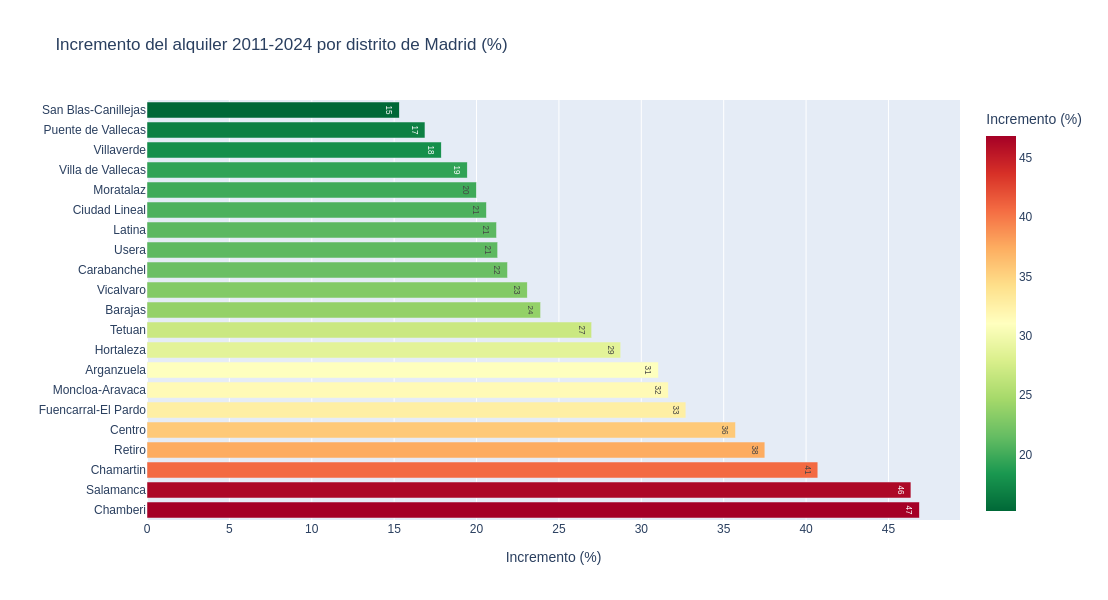

In [23]:
# Distritos de Madrid — códigos INE
DISTRITOS_MADRID = {
    "2807901": "Centro", "2807902": "Arganzuela", "2807903": "Retiro",
    "2807904": "Salamanca", "2807905": "Chamartin", "2807906": "Tetuan",
    "2807907": "Chamberi", "2807908": "Fuencarral-El Pardo", "2807909": "Moncloa-Aravaca",
    "2807910": "Latina", "2807911": "Carabanchel", "2807912": "Usera",
    "2807913": "Puente de Vallecas", "2807914": "Moratalaz", "2807915": "Ciudad Lineal",
    "2807916": "Hortaleza", "2807917": "Villaverde", "2807918": "Villa de Vallecas",
    "2807919": "Vicalvaro", "2807920": "San Blas-Canillejas", "2807921": "Barajas",
}

df_dist = query(f"""
    SELECT code, year,
        monthly_rent_median_collective as alquiler,
        rent_m2_median_collective as eur_m2
    FROM rentals
    WHERE level = 'distrito'
        AND code IN ({','.join(f"'{c}'" for c in DISTRITOS_MADRID)})
        AND year IN (2011, 2024)
        AND alquiler IS NOT NULL
    ORDER BY code, year
""").to_pandas()

df_dist["distrito"] = df_dist["code"].map(DISTRITOS_MADRID)

df_pivot = df_dist.pivot(index="distrito", columns="year", values="alquiler").reset_index()
df_pivot.columns = ["distrito", "alquiler_2011", "alquiler_2024"]
df_pivot["incremento_pct"] = ((df_pivot["alquiler_2024"] - df_pivot["alquiler_2011"]) / df_pivot["alquiler_2011"] * 100)
df_pivot = df_pivot.dropna().sort_values("incremento_pct", ascending=True)

fig = px.bar(
    df_pivot, x="incremento_pct", y="distrito", orientation="h",
    title="Incremento del alquiler 2011-2024 por distrito de Madrid (%)",
    labels={"incremento_pct": "Incremento (%)", "distrito": ""},
    text_auto=".0f",
    color="incremento_pct", color_continuous_scale="RdYlGn_r",
)
fig.update_layout(yaxis=dict(autorange="reversed"), width=900, height=600, showlegend=False)
fig.show()

## 5. Mapa de calor: alquiler EUR/m2 por distrito de Madrid (evolucion temporal)

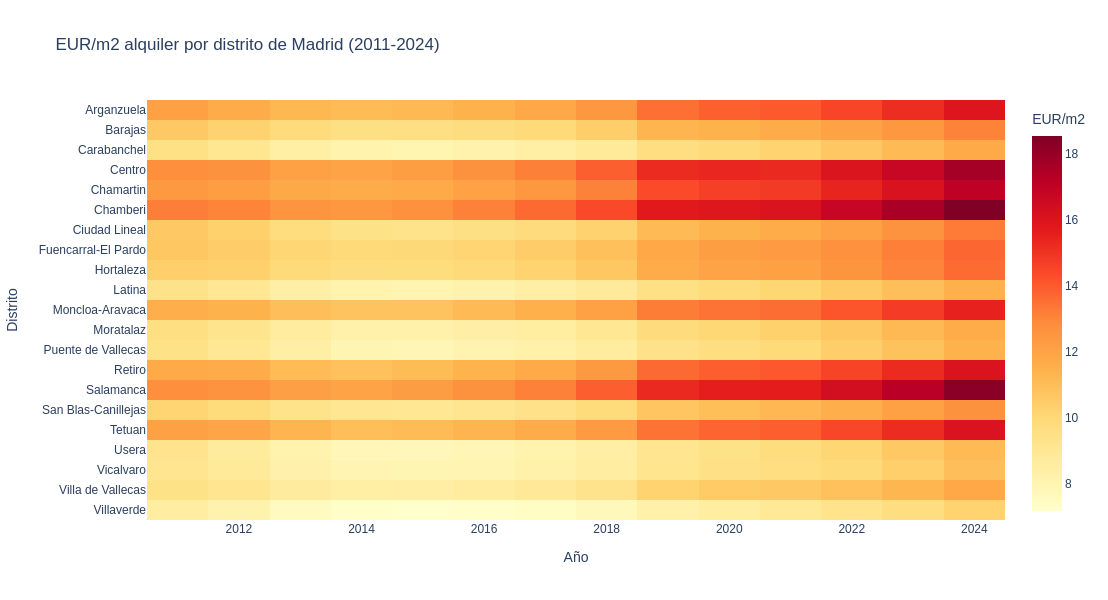

In [24]:
df_heat = query(f"""
    SELECT code, year, rent_m2_median_collective as eur_m2
    FROM rentals
    WHERE level = 'distrito'
        AND code IN ({','.join(f"'{c}'" for c in DISTRITOS_MADRID)})
        AND eur_m2 IS NOT NULL
    ORDER BY code, year
""").to_pandas()

df_heat["distrito"] = df_heat["code"].map(DISTRITOS_MADRID)
heatmap = df_heat.pivot(index="distrito", columns="year", values="eur_m2")

fig = px.imshow(
    heatmap, aspect="auto",
    title="EUR/m2 alquiler por distrito de Madrid (2011-2024)",
    labels=dict(x="Año", y="Distrito", color="EUR/m2"),
    color_continuous_scale="YlOrRd",
)
fig.update_layout(width=900, height=600)
fig.show()

## 6. IPV: Indice de Precios de Vivienda nacional (INE)

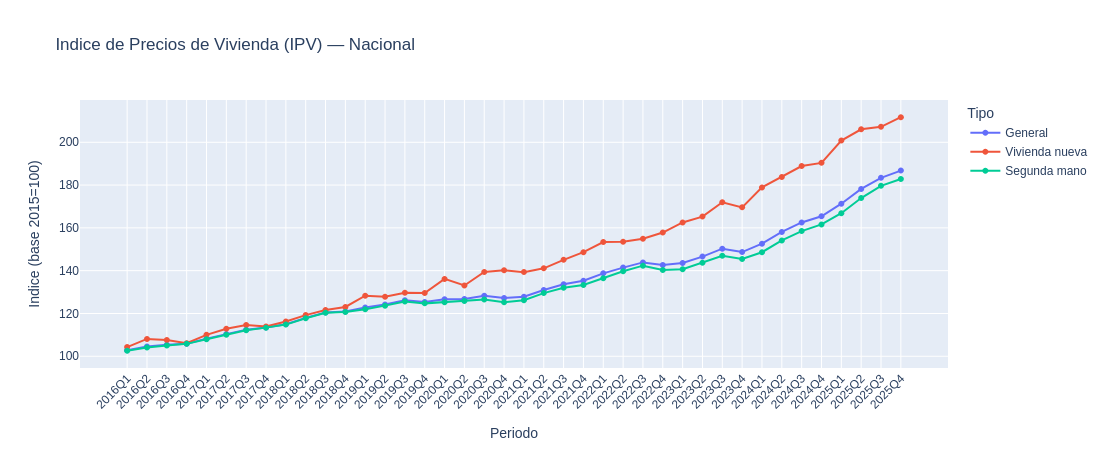

In [25]:
df_ipv = query("""
    SELECT category, year, quarter, value, period
    FROM ipv
    WHERE value IS NOT NULL
    ORDER BY category, year, quarter
""").to_pandas()

cat_labels = {
    "ipv_general": "General",
    "ipv_nueva": "Vivienda nueva",
    "ipv_segunda_mano": "Segunda mano",
}
df_ipv["tipo"] = df_ipv["category"].map(cat_labels)

fig = px.line(
    df_ipv, x="period", y="value", color="tipo",
    title="Indice de Precios de Vivienda (IPV) — Nacional",
    labels={"period": "Periodo", "value": "Indice (base 2015=100)", "tipo": "Tipo"},
    markers=True,
)
fig.update_layout(hovermode="x unified", width=900, height=450, xaxis_tickangle=-45)
fig.show()

## 7. Top 20 municipios mas caros de Espana (2024)

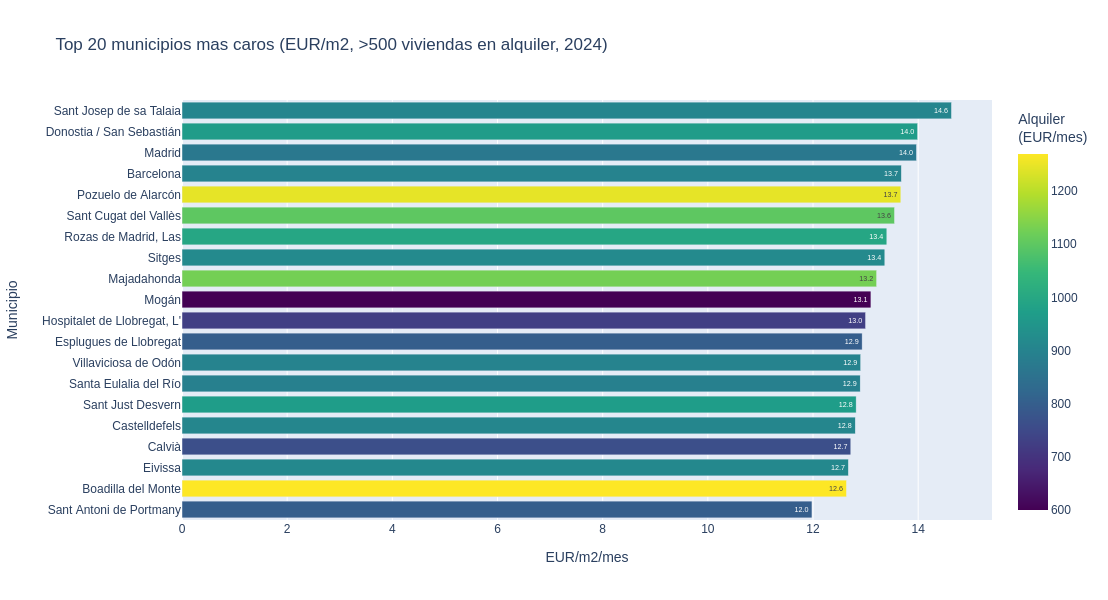

In [26]:
df_muni = query("""
    SELECT name,
        rent_m2_median_collective as eur_m2,
        monthly_rent_median_collective as alquiler,
        num_properties_collective as num_pisos
    FROM rentals
    WHERE level = 'municipio' AND year = 2024
        AND eur_m2 IS NOT NULL AND NOT isnan(eur_m2)
        AND alquiler IS NOT NULL AND NOT isnan(alquiler)
        AND num_pisos IS NOT NULL AND NOT isnan(num_pisos)
        AND num_pisos > 500
    ORDER BY eur_m2 DESC
    LIMIT 20
""")

fig = px.bar(
    df_muni.to_pandas(), x="eur_m2", y="name", orientation="h",
    title="Top 20 municipios mas caros (EUR/m2, >500 viviendas en alquiler, 2024)",
    labels={"eur_m2": "EUR/m2/mes", "name": "Municipio"},
    text_auto=".1f",
    color="alquiler", color_continuous_scale="Viridis",
    hover_data=["alquiler", "num_pisos"],
)
fig.update_layout(
    yaxis=dict(autorange="reversed"), width=900, height=600,
    coloraxis_colorbar_title="Alquiler<br>(EUR/mes)",
)
fig.show()

## 8. Crecimiento del mercado: numero de viviendas en alquiler por CCAA

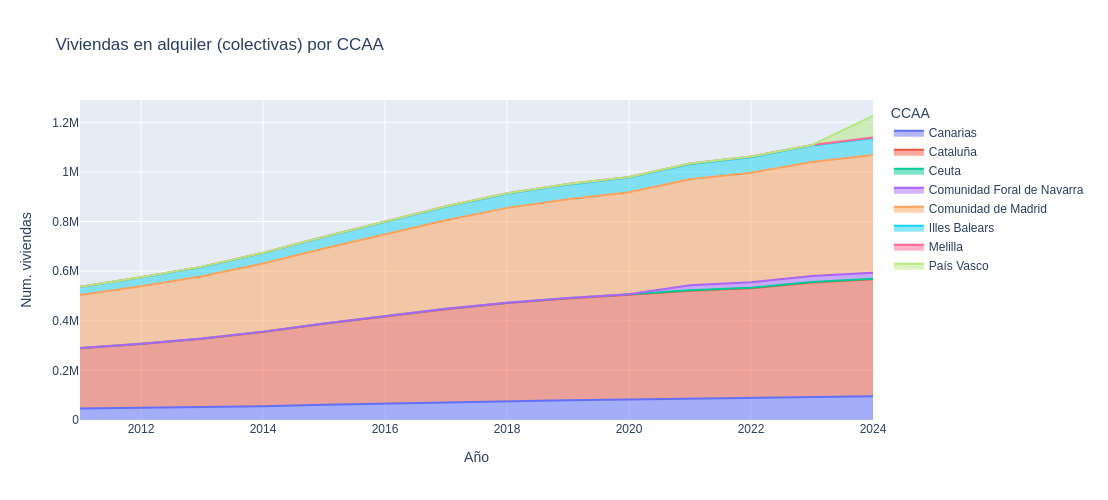

In [27]:
df_vol = query("""
    SELECT name, year,
        num_properties_collective as viviendas
    FROM rentals
    WHERE level = 'ccaa'
        AND name IS NOT NULL AND name != ''
        AND viviendas IS NOT NULL AND NOT isnan(viviendas)
        AND viviendas > 0
    ORDER BY name, year
""")

df_vol_top = df_vol.filter(pl.col("name").is_in(top_ccaa))

fig = px.area(
    df_vol_top.to_pandas(), x="year", y="viviendas", color="name",
    title="Viviendas en alquiler (colectivas) por CCAA",
    labels={"year": "Año", "viviendas": "Num. viviendas", "name": "CCAA"},
)
fig.update_layout(hovermode="x unified", width=900, height=500)
fig.show()